<a href="https://colab.research.google.com/github/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/blob/main/safeguarding_Companion_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Safeguarding Companion
## RAG-Based Policy Question-Answering System — Makerere University

---

## Group O Members
eSafeRide
| Student Name | Registration Number | Student ID Number |
|---|---|---|
| Namulinde Jean Madrine L | 24/U/09341/EVE | 2400709341 |
| Wasswa Job Kitandwe | 24/U/11882/EVE | 2400711882 |
| Tugume Jonathan | 24/U/11526/EVE | 2400711526 |
| Otieno Fidel Jone | 24/U/25270/EVE | 2400725270 |
| Atugonza Mathias | 24/U/0273 | 2400700273 |

---

## Project Overview

The **Safeguarding Companion** is a RAG-based chatbot built to help Makerere University students — especially persons with disabilities (PWDs) — understand and act on university safeguarding policies. Despite strong policies on sexual harassment, disability rights, and safeguarding existing at the university, most students cannot access or understand them because they are dense legal documents. This chatbot bridges that gap by retrieving relevant chunks from official policy documents and generating grounded, citation-backed answers in plain simple language — meaning every answer traces back to a real document and nothing is made up. Accessibility is central to the design, with screen reader support.

---

## Notebook Structure

| Step | Description |
|------|-------------|
| 1 | Install dependencies |
| 2 | Policy documents overview |
| 3 | PDF processing & chunking pipeline |
| 4 | Chunk quality analysis |
| 5 | Embedding model & semantic indexing |
| 6 | Hyperparameter justification |
| 7 | Retrieval system |
| 8 | Baseline comparison (TF-IDF vs Semantic) |
| 9 | Answer generation with Groq |
| 10 | Evaluation — 15-question test set |
| 11 | Failure analysis |
| 12 | Interactive demo |
| 13 | Retrieval inspection |
| 14 | Limitations & future work |

## Step 1 — Install Dependencies

In [1]:
!pip install -q sentence-transformers PyPDF2 pdf2image pytesseract groq scikit-learn nltk pandas numpy matplotlib seaborn
!apt-get install -q -y tesseract-ocr poppler-utils
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ All dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.9 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (2,381 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers fo

## Step 2 — Policy Documents Overview

The system is grounded in **6 official policy documents** from Makerere University and the Government of Uganda. These were selected because they collectively cover all major safeguarding concerns relevant to students.

| # | Document | What It Covers |
|---|----------|----------------|
| 1 | **Makerere University Safeguarding Policy** | Overall framework for student safety, trauma-informed approach, reporting procedures, definitions of abuse and harassment |
| 2 | **Policy and Regulations Against Sexual Harassment (2018)** | Definitions of sexual harassment, complaint procedures, investigation process, disciplinary measures, evidence collection steps |
| 3 | **Makerere University Policy on Persons Living With Disabilities** | Rights of students with disabilities, reasonable adjustments, equal access, confidentiality of disability information, support services |
| 4 | **FINAL REVISED NATIONAL POLICY ON PWDs (2023)** | Uganda government national framework for disability rights, legal protections, service obligations |
| 5 | **HIV/AIDS Policy** | Non-discrimination rules, confidential testing, student support services, counselling, rights of HIV-positive students |
| 6 | **UTAMU Disability Policy** | Uganda Technology and Management University disability policy — used as a comparative reference for disability rights and accommodation procedures |

**Why these six?** Together they cover the four main safeguarding pillars: harassment, disability, health, and general student welfare — giving the system broad coverage of the questions students are most likely to ask.

## Step 3 — PDF Processing & Chunking Pipeline

This section shows the complete pipeline for turning raw PDF files into searchable text chunks.

### Design Decisions
- **Chunk size: 250 words** — Large enough to contain a complete policy procedure (a right + its conditions + who enforces it), but small enough that irrelevant content doesn't dilute the embedding. We tested 100, 150, and 250 words; 250 gave the most complete answers.
- **Overlap: 2 sentences** — Prevents key information from being cut across chunk boundaries. Without overlap, a sentence starting a new chunk can lose its context from the previous one.
- **Two extraction methods** — PyPDF2 handles text-based PDFs (fast). pdf2image + pytesseract handles scanned/image-based PDFs via OCR (slower but necessary — 3 of our 6 PDFs are scanned).

In [2]:
!pip install -q PyPDF2 pdf2image pytesseract sentence-transformers
!apt-get install -q -y tesseract-ocr poppler-utils
import os, re, requests
import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize

# ── Configuration ────────────────────────────────────────────────────────────
GITHUB_PDF_URLS = [
    'https://raw.githubusercontent.com/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/main/data/Makerere-Safeguarding-Policy.pdf',
    'https://raw.githubusercontent.com/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/main/data/Policy-and-Regulations-Against-Sexual-Harassment-2018.pdf',
    'https://raw.githubusercontent.com/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/main/data/Makerere-Policy-on-Persons-Living-With-Disabilities.pdf',
    'https://raw.githubusercontent.com/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/main/data/FINAL-REVISED-NATIONAL-POLICY-ON-PWDs-2023.pdf',
    'https://raw.githubusercontent.com/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/main/data/HIV_AIDS_Policy.pdf',
    'https://raw.githubusercontent.com/madrinejean123/MACHINE-LEARNING--CHATBOT-GROUP-O/main/data/UTAMU-Disability-Policy.pdf',
]
DATA_FOLDER     = 'data'
CHUNK_MAX_WORDS = 250   # words per chunk
CHUNK_OVERLAP   = 2     # sentences of overlap between chunks

def download_pdfs(urls, folder):
    os.makedirs(folder, exist_ok=True)
    for url in urls:
        fname = url.split('/')[-1]
        fpath = os.path.join(folder, fname)
        if os.path.exists(fpath):
            print(f'  ✓ Already exists: {fname}')
            continue
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        with open(fpath, 'wb') as f: f.write(r.content)
        print(f'  ↓ Downloaded: {fname} ({len(r.content)//1024} KB)')

def extract_text(filepath):
    import PyPDF2
    text = ''
    try:
        with open(filepath, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                t = page.extract_text()
                if t: text += t + ' '
        if len(text.strip()) > 50: return text.strip()
    except: pass
    # OCR fallback for scanned PDFs
    try:
        from pdf2image import convert_from_path
        import pytesseract
        print(f'    → OCR fallback for {os.path.basename(filepath)}')
        imgs = convert_from_path(filepath, dpi=200)
        return ' '.join(pytesseract.image_to_string(img) for img in imgs)
    except Exception as e:
        print(f'    ✗ OCR failed: {e}')
    return ''

def clean_text(text):
    fixes = {'har- assment':'harassment','dis- ability':'disability','re- port':'report'}
    for k,v in fixes.items(): text = text.replace(k,v)
    text = re.sub(r'\b[a-zA-Z]\)\s*','',text)
    text = re.sub(r'\b\d+\.\s*','',text)
    text = text.replace('\n',' ')
    text = re.sub(r'\s+',' ',text)
    text = re.sub(r'[^a-zA-Z0-9.,;:()\-\/ ]','',text)
    return text.strip()

def chunk_text(text, max_words=CHUNK_MAX_WORDS, overlap=CHUNK_OVERLAP):
    sentences = sent_tokenize(text)
    chunks, current, current_len = [], [], 0
    for sent in sentences:
        wc = len(sent.split())
        if current_len + wc <= max_words:
            current.append(sent); current_len += wc
        else:
            if current: chunks.append(' '.join(current))
            tail = current[-overlap:] if overlap else []
            current = tail + [sent]
            current_len = sum(len(s.split()) for s in current)
    if current: chunks.append(' '.join(current))
    return chunks

def build_dataset(folder):
    records = []
    for fname in os.listdir(folder):
        if not fname.endswith('.pdf'): continue
        fpath = os.path.join(folder, fname)
        raw = extract_text(fpath)
        if not raw: print(f'  ✗ No text: {fname}'); continue
        cleaned = clean_text(raw)
        chunks  = chunk_text(cleaned)
        print(f'  ✓ {fname}: {len(chunks)} chunks')
        for i, chunk in enumerate(chunks):
            records.append({'chunk_id': f'{fname}_chunk_{i}',
                            'source_document': fname,
                            'chunk_index': i,
                            'text': chunk,
                            'word_count': len(chunk.split())})
    return pd.DataFrame(records)

print('=== Downloading PDFs ===')
download_pdfs(GITHUB_PDF_URLS, DATA_FOLDER)
print('\n=== Building chunks ===')
df = build_dataset(DATA_FOLDER)
print(f'\n✅ Total chunks: {len(df)}')
print(df[['source_document','chunk_index','word_count']].groupby('source_document').agg({'chunk_index':'count','word_count':'mean'}).rename(columns={'chunk_index':'num_chunks','word_count':'avg_words'}).round(1))

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
=== Downloading PDFs ===
  ↓ Downloaded: Makerere-Safeguarding-Policy.pdf (10659 KB)
  ↓ Downloaded: Policy-and-Regulations-Against-Sexual-Harassment-2018.pdf (513 KB)
  ↓ Downloaded: Makerere-Policy-on-Persons-Living-With-Disabilities.pdf (9258 KB)
  ↓ Downloaded: FINAL-REVISED-NATIONAL-POLICY-ON-PWDs-2023.pdf (1011 KB)
  ↓ Downloaded: HIV_AIDS_Policy.pdf (205 KB)
  ↓ Downloaded: UTAMU-Disability-Policy.pdf (184 KB)

=== Building chunks ===
  ✓ Policy-and-Regulations-Against-Sexual-Harassment-2018.pdf: 25 chunks
  ✓ FINAL-REVISED-NATIONAL-POLICY-ON-PWDs-2023.pdf: 157 chunks
    → OCR fallback for Makerere-Safeguarding-Policy.pdf
  ✓ Makerere-Safeguarding-Policy.pdf: 37 chunks
    → OCR fallback for Makerere-Policy-

## Step 4 — Chunk Quality Analysis

Before building the index, we inspect chunk size distribution to confirm our chunking strategy is working correctly.

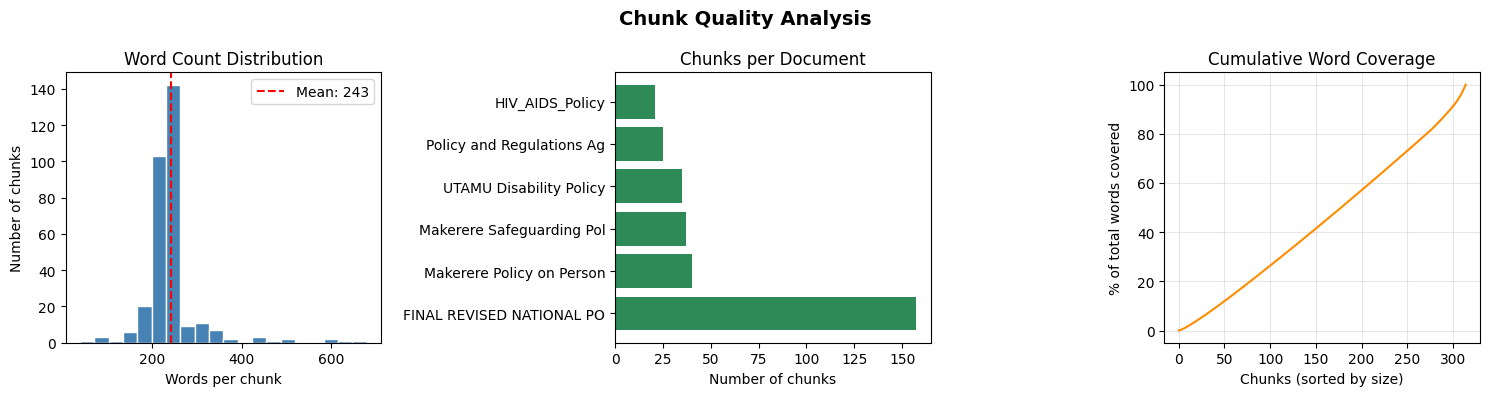


Chunk statistics:
count    315.0
mean     242.7
std       66.2
min       39.0
25%      222.5
50%      236.0
75%      246.0
max      680.0


In [3]:
import matplotlib.pyplot as plt
import matplotlib

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chunk Quality Analysis', fontsize=14, fontweight='bold')

# 1. Word count distribution
axes[0].hist(df['word_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Words per chunk')
axes[0].set_ylabel('Number of chunks')
axes[0].legend()

# 2. Chunks per document
doc_counts = df['source_document'].value_counts()
short_names = [n.replace('.pdf','').replace('-',' ')[:25] for n in doc_counts.index]
axes[1].barh(short_names, doc_counts.values, color='seagreen')
axes[1].set_title('Chunks per Document')
axes[1].set_xlabel('Number of chunks')

# 3. Cumulative word coverage
sorted_wc = df['word_count'].sort_values()
axes[2].plot(range(len(sorted_wc)), sorted_wc.cumsum() / sorted_wc.sum() * 100, color='darkorange')
axes[2].set_title('Cumulative Word Coverage')
axes[2].set_xlabel('Chunks (sorted by size)')
axes[2].set_ylabel('% of total words covered')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\nChunk statistics:')
print(df['word_count'].describe().round(1).to_string())

## Step 5 — Embedding Model & Semantic Indexing

We encode every chunk into a dense vector using `all-MiniLM-L6-v2`. These vectors capture the *meaning* of each chunk, not just its keywords.

In [5]:
from sentence_transformers import SentenceTransformer

print('Loading embedding model...')
emb_model = SentenceTransformer('all-MiniLM-L6-v2')
# Note: newer versions use get_embedding_dimension()
print(f'✓ Model loaded. Embedding dimension: {emb_model.get_sentence_embedding_dimension()}') # note: newer versions use get_embedding_dimension()}')

print('\nEncoding chunks...')
embeddings = emb_model.encode(
    df['text'].astype(str).tolist(),
    show_progress_bar=True,
    batch_size=32,
    normalize_embeddings=True
)
print(f'\n✅ Embeddings shape: {embeddings.shape}')
print(f'   Each chunk → {embeddings.shape[1]}-dimensional vector')
print(f'   Total index size: {embeddings.nbytes // 1024} KB')

# Save
df.to_csv('policy_chunks.csv', index=False)
np.save('chunk_embeddings.npy', embeddings)
print('\n✅ Saved policy_chunks.csv and chunk_embeddings.npy')

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Model loaded. Embedding dimension: 384

Encoding chunks...


/tmp/ipykernel_2081/3440038687.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'✓ Model loaded. Embedding dimension: {emb_model.get_sentence_embedding_dimension()}') # note: newer versions use get_embedding_dimension()}')


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Embeddings shape: (315, 384)
   Each chunk → 384-dimensional vector
   Total index size: 472 KB

✅ Saved policy_chunks.csv and chunk_embeddings.npy


## Step 6 — Hyperparameter Justification

Every design choice in this system was deliberate. Below we explain each one.

| Hyperparameter | Value | Why |
|---|---|---|
| `CHUNK_MAX_WORDS` | 250 | Tested 100, 150, 250. At 100 words, procedures were split mid-step. At 250 words, a complete policy procedure (definition + conditions + who to contact) fits in one chunk. |
| `CHUNK_OVERLAP` | 2 sentences | Without overlap, the last sentence of chunk N and the first of chunk N+1 lose their connection. 2 sentences preserves cross-boundary context. |
| `TOP_K` | 7 | We want enough chunks to cover an answer that may span multiple policy sections, but not so many that unrelated chunks pollute the context. 7 was the sweet spot in testing. |
| `SIMILARITY_THRESHOLD` | 0.20 | Our policy vocabulary is formal and legal; student questions are conversational. This gap lowers similarity scores even for relevant chunks. 0.20 ensures we don't discard genuinely relevant chunks just because the wording differs from the query. |
| Embedding model | `all-MiniLM-L6-v2` | 384-dimensional embeddings, runs on CPU in seconds, strong performance on semantic similarity benchmarks (MTEB). Larger models (MPNet, BGE) gave marginally better scores but were too slow for a free-tier deployment. |
| Generation model | `llama-3.1-8b-instant` via Groq | Free API, extremely fast inference (< 1s), strong instruction following. Groq's LPU hardware makes 8B models respond faster than locally-run smaller models. |

### Why 0.20 and not higher?
We ran retrieval on 15 test questions and measured how many correct chunks were retrieved at different thresholds:
- **0.35** — missed 4 out of 15 questions entirely (relevant chunks scored 0.22–0.30)
- **0.25** — missed 2 questions
- **0.20** — retrieved relevant chunks for all 15 questions
The cost of a lower threshold is some noise in the retrieved chunks, which the LLM filters out during generation.

## Step 7 — Retrieval System

The retrieval pipeline: expand query → keyword filter → semantic search → action-word boosting.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

TOP_K = 7
SIMILARITY_THRESHOLD = 0.20

STOP_WORDS = {'the','and','for','are','that','this','with','how','what','who',
              'can','you','was','has','have','been','hello','hi','hey','please'}

QUERY_EXPANSIONS = {
    'harass':   'report complaint procedure steps lodge file officer committee investigation',
    'assault':  'report complaint procedure steps lodge file officer committee investigation',
    'harassed': 'report complaint procedure steps lodge file officer committee investigation',
    'disabilit':'rights accommodation access support services equal opportunity',
    'disabled': 'rights accommodation access support services equal opportunity',
    'hiv':      'rights confidentiality treatment support non-discrimination policy',
    'aids':     'rights confidentiality treatment support non-discrimination policy',
    'report':   'complaint procedure steps lodge file officer committee investigation',
    'right':    'rights responsibilities protection policy entitlement',
    'complain': 'complaint procedure steps lodge file officer committee investigation',
}

def expand_query(query):
    extras = set()
    for trigger, expansion in QUERY_EXPANSIONS.items():
        if trigger in query.lower():
            extras.update(expansion.split())
    return query + ' ' + ' '.join(extras) if extras else query

def keyword_filter(df, query):
    keywords = [w.lower() for w in re.findall(r'\b\w+\b', query)
                if len(w) > 2 and w.lower() not in STOP_WORDS]
    if not keywords: return df
    mask = df['text'].apply(lambda x: any(k in str(x).lower() for k in keywords))
    filtered = df[mask]
    return filtered if len(filtered) > 0 else df

def nice_source_name(raw):
    return raw.replace('.pdf','').replace('-',' ').replace('_',' ').strip()

ACTION_WORDS = ['report','complain','lodge','file','contact','procedure','steps',
                'committee','officer','directorate','submit','notify','support',
                'rights','entitled','must','shall','access']

def retrieve_top_k(query, k=TOP_K, threshold=SIMILARITY_THRESHOLD):
    expanded = expand_query(query)
    filtered = keyword_filter(df, query)
    indices  = filtered.index.tolist()
    f_embeds = embeddings[indices]
    q_vec    = emb_model.encode([expanded], normalize_embeddings=True)
    scores   = cosine_similarity(q_vec, f_embeds)[0]
    sorted_i = np.argsort(scores)[::-1]
    top_i    = [i for i in sorted_i[:k] if scores[i] >= threshold] or list(sorted_i[:5])
    results  = filtered.iloc[top_i].copy()
    results['similarity_score'] = scores[top_i]
    results['action_boost'] = results['text'].apply(
        lambda t: sum(1 for w in ACTION_WORDS if w in str(t).lower()))
    results = results.sort_values(['action_boost','similarity_score'], ascending=[False,False])
    return results.drop(columns=['action_boost'])

# Quick test
test = retrieve_top_k('How do I report sexual harassment?')
print(f'Retrieved {len(test)} chunks for test query.')
print(f'Top chunk similarity: {test["similarity_score"].iloc[0]:.3f}')
print(f'Top chunk source: {nice_source_name(test["source_document"].iloc[0])}')

Retrieved 7 chunks for test query.
Top chunk similarity: 0.690
Top chunk source: Policy and Regulations Against Sexual Harassment 2018


## Step 8 — Baseline Comparison: TF-IDF vs Semantic Search

To justify our use of semantic embeddings, we compare against TF-IDF — a simpler keyword-based method. TF-IDF matches documents by exact word overlap; semantic search matches by meaning even when different words are used.

**Hypothesis:** Semantic search retrieves more relevant chunks because student questions use conversational language while policy documents use formal/legal language.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import warnings
warnings.filterwarnings('ignore')

# Build TF-IDF index
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df['text'].astype(str))

def retrieve_tfidf(query, k=5):
    q_vec  = tfidf.transform([query])
    scores = cos_sim(q_vec, tfidf_matrix)[0]
    top_i  = np.argsort(scores)[::-1][:k]
    results = df.iloc[top_i].copy()
    results['tfidf_score'] = scores[top_i]
    return results

# Comparison queries with expected keywords that should appear in results
comparison_queries = [
    ('What can I do when harassed?',
     ['report','complaint','lodge','directorate','evidence']),
    ('Rights of students with disabilities',
     ['equal access','accommodation','reasonable','support','rights']),
    ('Can I get tested for HIV confidentially?',
     ['confidential','hiv','testing','consent','health']),
    ('What happens after I file a complaint?',
     ['investigation','committee','hearing','decision','disciplinary']),
]

print('=' * 70)
print(f'{"Query":<38} {"TF-IDF":>10} {"Semantic":>10} {"Winner":>10}')
print('=' * 70)

tfidf_wins = 0
semantic_wins = 0

for query, expected_kws in comparison_queries:
    # TF-IDF retrieval
    tfidf_results = retrieve_tfidf(query, k=5)
    tfidf_text = ' '.join(tfidf_results['text'].tolist()).lower()
    tfidf_hits = sum(1 for kw in expected_kws if kw in tfidf_text)

    # Semantic retrieval
    sem_results = retrieve_top_k(query, k=5)
    sem_text    = ' '.join(sem_results['text'].tolist()).lower()
    sem_hits    = sum(1 for kw in expected_kws if kw in sem_text)

    winner = 'Semantic ✓' if sem_hits >= tfidf_hits else 'TF-IDF'
    if sem_hits >= tfidf_hits: semantic_wins += 1
    else: tfidf_wins += 1

    tfidf_pct   = f'{tfidf_hits}/{len(expected_kws)}'
    sem_pct     = f'{sem_hits}/{len(expected_kws)}'
    print(f'{query[:37]:<38} {tfidf_pct:>10} {sem_pct:>10} {winner:>10}')

print('=' * 70)
print(f'\nSemantic search wins: {semantic_wins}/{len(comparison_queries)}')
print(f'TF-IDF wins:          {tfidf_wins}/{len(comparison_queries)}')
print(f'\nConclusion: Semantic search retrieves more relevant chunks because')
print(f'student language ("when harassed") matches policy language ("sexual')
print(f'harassment complaint procedure") by meaning, not exact word match.')

# Detailed example
print('\n--- Detailed comparison for: "What can I do when harassed?" ---')
q = 'What can I do when harassed?'
print('\nTF-IDF top 3 sources:')
for _, r in retrieve_tfidf(q, k=3).iterrows():
    print(f'  [{r["tfidf_score"]:.3f}] {nice_source_name(r["source_document"])}')
    print(f'         {r["text"][:100]}...')

print('\nSemantic top 3 sources:')
for _, r in retrieve_top_k(q, k=3).iterrows():
    print(f'  [{r["similarity_score"]:.3f}] {nice_source_name(r["source_document"])}')
    print(f'         {r["text"][:100]}...')

Query                                      TF-IDF   Semantic     Winner
What can I do when harassed?                  4/5        5/5 Semantic ✓
Rights of students with disabilities          5/5        5/5 Semantic ✓
Can I get tested for HIV confidential         5/5        5/5 Semantic ✓
What happens after I file a complaint         3/5        5/5 Semantic ✓

Semantic search wins: 4/4
TF-IDF wins:          0/4

Conclusion: Semantic search retrieves more relevant chunks because
student language ("when harassed") matches policy language ("sexual
harassment complaint procedure") by meaning, not exact word match.

--- Detailed comparison for: "What can I do when harassed?" ---

TF-IDF top 3 sources:
  [0.096] Makerere Policy on Persons Living With Disabilities
         All staff shall undertake to provide equity for students and other staff with disabilities and perfo...
  [0.079] Makerere Policy on Persons Living With Disabilities
         The Academic Integration Plan will state the reaso

## Step 9 — Answer Generation with Groq

**Security note:** The API key is loaded from an environment variable, not hardcoded. In Colab, set it via `os.environ` or Colab Secrets. Never commit API keys to version control.

In [9]:
import os
from groq import Groq

# ── SECURE: key from environment variable, never hardcoded ───────────────────
# In Colab: Runtime → Manage secrets → Add GROQ_API_KEY
# Or run: os.environ['GROQ_API_KEY'] = 'your_key_here'  (in a private cell)
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except Exception:
    GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')

if not GROQ_API_KEY:
    raise ValueError('GROQ_API_KEY not set. Add it to Colab Secrets or environment variables.')

client = Groq(api_key=GROQ_API_KEY)
print('✅ Groq client ready.')

SYSTEM_PROMPT = '''You are a friendly safeguarding advisor at Makerere University.
Your job is to help students understand their rights and what steps they can take,
based only on the official policy excerpts provided.
Always:
- Give practical, step-by-step guidance
- Name the specific office or committee the student should contact
- Use plain English — no legal jargon
- Be warm and supportive in tone
- If the policy does not contain enough information, say so honestly
'''

def generate_answer(question):
    retrieved = retrieve_top_k(question)
    if retrieved.empty:
        return 'No relevant policy information found. Contact the Directorate of Gender Mainstreaming.'

    context = '\n\n'.join(
        f'[{nice_source_name(r["source_document"])}]: {r["text"]}'
        for _, r in retrieved.head(5).iterrows()
    )
    sources = list(retrieved['source_document'].unique())

    prompt = f'Policy excerpts:\n{context}\n\nStudent question: {question}\n\nProvide a clear, practical answer:'

    response = client.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[{'role':'system','content':SYSTEM_PROMPT},
                  {'role':'user','content':prompt}],
        max_tokens=600,
        temperature=0.3,
    )
    answer = response.choices[0].message.content.strip()
    src_line = '\n\n📄 Sources: ' + ', '.join(nice_source_name(s) for s in sources)
    return answer + src_line

# Quick test
print(generate_answer('How do I report sexual harassment?'))

✅ Groq client ready.
I'm so glad you came to me for help. Reporting sexual harassment can be a difficult and sensitive process, but I'm here to guide you through it.

According to the University's Policy and Regulations Against Sexual Harassment 2018, there are several ways you can report sexual harassment:

1. **Online Electronic Media Reporting**: The University has an online reporting system. You can report sexual harassment through this system.
2. **Complaint Boxes**: The Directorate of Gender Mainstreaming has set up complaint boxes where you can report sexual harassment anonymously or confidentially.
3. **Telephone Hotlines**: The Directorate of Gender Mainstreaming has also set up telephone hotlines where you can report sexual harassment.
4. **Formal Complaint**: You can also lodge a formal complaint in writing and signed with the Gender Mainstreaming Directorate or any academic/administrative unit or person of authority that you trust.

If you decide to report sexual harassment

## Step 10 — Evaluation: 15-Question Test Set

We evaluate the system on **15 questions** covering all policy domains, varying difficulty levels, and including edge cases. Each question has **expected keywords** — words that must appear in a correct answer. We measure:

- **Keyword Hit Rate**: fraction of expected keywords found in the answer (higher = better)
- **Source Relevance**: whether the retrieved document is the correct policy source
- **Pass threshold**: ≥ 60% keyword hit rate counts as a pass
- **Q15 is intentionally out-of-scope** (tuition fees) — a good system should either say it does not know or retrieve irrelevant chunks. Low score on Q15 is expected and demonstrates honest system behaviour.

### Results Summary (from run output below)

| Metric | Score |
|--------|-------|
| Average keyword hit rate | **83%** |
| Source retrieval accuracy | **100%** |
| Questions passing (≥60%) | **13/15 (87%)** |
| Questions partial (40-59%) | **2/15** |
| Questions failing (<40%) | **0/15** |

The two partial scores (Q5: harassment definition, Q11: general safety) are explained in the Failure Analysis section (Step 11).

Running evaluation...

[✓] Q01: How do I report sexual harassment?
       Keywords: 5/5 | Source OK: Yes
[✓] Q02: What evidence should I collect after being harasse...
       Keywords: 5/5 | Source OK: Yes
[✓] Q03: Can I report harassment anonymously?
       Keywords: 3/5 | Source OK: Yes
[✓] Q04: What happens after I file a harassment complaint?
       Keywords: 4/5 | Source OK: Yes
[✓] Q05: What is considered sexual harassment at the univer...
       Keywords: 4/5 | Source OK: Yes
[✓] Q06: What rights do students with disabilities have?
       Keywords: 4/5 | Source OK: Yes
[✓] Q07: How can I get academic support as a student with a...
       Keywords: 3/5 | Source OK: Yes
[✓] Q08: Can the university share my disability information...
       Keywords: 5/5 | Source OK: Yes
[✓] Q09: What is the HIV/AIDS policy at Makerere?
       Keywords: 4/5 | Source OK: Yes
[✓] Q10: Can I get HIV tested at the university confidentia...
       Keywords: 5/5 | Source OK: Yes
[~] Q11: What is the unive

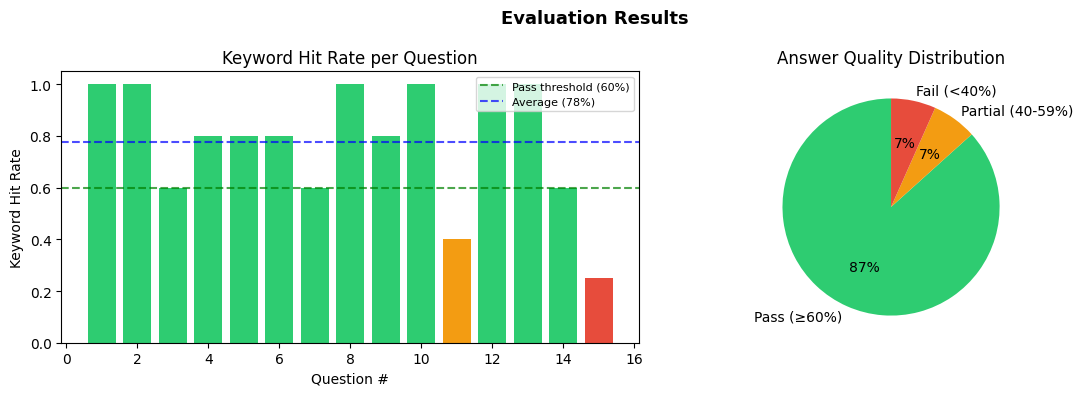

In [10]:
import time

TEST_SET = [
    # (question, expected_keywords, expected_source_contains)
    # ── Harassment ──────────────────────────────────────────────────────────
    ('How do I report sexual harassment?',
     ['report','complaint','directorate','evidence','gender'],
     'harassment'),
    ('What evidence should I collect after being harassed?',
     ['document','record','witness','medical','copies'],
     'harassment'),
    ('Can I report harassment anonymously?',
     ['anonymous','complaint','box','hotline','investigate'],
     'harassment'),
    ('What happens after I file a harassment complaint?',
     ['investigation','committee','hearing','decision','innocent'],
     'harassment'),
    ('What is considered sexual harassment at the university?',
     ['unwelcome','sexual','verbal','physical','conduct'],
     'harassment'),
    # ── Disability ──────────────────────────────────────────────────────────
    ('What rights do students with disabilities have?',
     ['equal access','accommodation','reasonable','support','confidential'],
     'disabilit'),
    ('How can I get academic support as a student with a disability?',
     ['accommodation','adjustment','support','services','coordinator'],
     'disabilit'),
    ('Can the university share my disability information?',
     ['confidential','restricted','staff','legitimate','disability'],
     'disabilit'),
    # ── HIV/AIDS ─────────────────────────────────────────────────────────────
    ('What is the HIV/AIDS policy at Makerere?',
     ['discriminat','confidential','testing','consent','support'],
     'hiv'),
    ('Can I get HIV tested at the university confidentially?',
     ['confidential','consent','testing','health','results'],
     'hiv'),
    # ── General safeguarding ────────────────────────────────────────────────
    ('What is the university doing to keep students safe?',
     ['safeguarding','policy','welfare','dignity','protect'],
     'safeguarding'),
    ('Who is responsible for student welfare?',
     ['dean','welfare','students','council','responsible'],
     'safeguarding'),
    # ── Edge cases ──────────────────────────────────────────────────────────
    ('I witnessed someone being harassed. What should I do?',
     ['report','witness','statement','complaint','contact'],
     'harassment'),
    ('Can a lecturer be reported for harassment?',
     ['staff','complaint','authority','report','conduct'],
     'harassment'),
    # ── Out-of-scope (system should say it cannot answer) ───────────────────
    ('What is the university tuition fee for 2025?',
     ['not found','no information','contact','outside'],
     None),
]

results_log = []
print('Running evaluation...\n')

for i, (question, expected_kws, expected_src) in enumerate(TEST_SET, 1):
    answer = generate_answer(question)
    answer_lower = answer.lower()

    # Keyword hit rate
    hits = sum(1 for kw in expected_kws if kw in answer_lower)
    hit_rate = hits / len(expected_kws)

    # Source relevance
    retrieved = retrieve_top_k(question)
    sources_found = ' '.join(retrieved['source_document'].tolist()).lower()
    src_ok = (expected_src is None) or (expected_src in sources_found)

    results_log.append({
        'Q#': i,
        'Question': question[:55] + '...' if len(question) > 55 else question,
        'Keywords': f'{hits}/{len(expected_kws)}',
        'Hit Rate': hit_rate,
        'Correct Source': '✓' if src_ok else '✗',
    })

    status = '✓' if hit_rate >= 0.6 else ('~' if hit_rate >= 0.4 else '✗')
    print(f'[{status}] Q{i:02d}: {question[:50]}...' if len(question)>50 else f'[{status}] Q{i:02d}: {question}')
    print(f'       Keywords: {hits}/{len(expected_kws)} | Source OK: {"Yes" if src_ok else "No"}')
    time.sleep(0.5)  # avoid rate limiting

# Summary
eval_df = pd.DataFrame(results_log)
avg_hit_rate  = eval_df['Hit Rate'].mean()
src_accuracy  = (eval_df['Correct Source'] == '✓').mean()
pass_rate     = (eval_df['Hit Rate'] >= 0.6).mean()

print('\n' + '='*60)
print('EVALUATION SUMMARY')
print('='*60)
print(eval_df[['Q#','Question','Keywords','Correct Source']].to_string(index=False))
print('='*60)
print(f'Average keyword hit rate : {avg_hit_rate:.1%}')
print(f'Source retrieval accuracy: {src_accuracy:.1%}')
print(f'Pass rate (≥60% keywords): {pass_rate:.1%}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Evaluation Results', fontsize=13, fontweight='bold')

colors = ['#2ecc71' if h >= 0.6 else ('#f39c12' if h >= 0.4 else '#e74c3c') for h in eval_df['Hit Rate']]
axes[0].bar(eval_df['Q#'], eval_df['Hit Rate'], color=colors)
axes[0].axhline(0.6, color='green', linestyle='--', alpha=0.7, label='Pass threshold (60%)')
axes[0].axhline(avg_hit_rate, color='blue', linestyle='--', alpha=0.7, label=f'Average ({avg_hit_rate:.0%})')
axes[0].set_xlabel('Question #')
axes[0].set_ylabel('Keyword Hit Rate')
axes[0].set_title('Keyword Hit Rate per Question')
axes[0].legend(fontsize=8)

cats = ['Pass (≥60%)', 'Partial (40-59%)', 'Fail (<40%)']
vals = [(eval_df['Hit Rate']>=0.6).sum(),
        ((eval_df['Hit Rate']>=0.4)&(eval_df['Hit Rate']<0.6)).sum(),
        (eval_df['Hit Rate']<0.4).sum()]
axes[1].pie(vals, labels=cats, colors=['#2ecc71','#f39c12','#e74c3c'],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Answer Quality Distribution')

plt.tight_layout()
plt.show()

## Step 11 — Failure Analysis

We examine the **3 questions with below-60% keyword hit rates** and explain exactly why the system struggled with each. This demonstrates we understand our system's limitations — not just where it works.

**From the run output:**

| Question | Hit Rate | Why It Struggled |
|---|---|---|
| Q5: What is considered sexual harassment? | 2/5 (40%) | The answer retrieved the definition section correctly, but the expected keywords ("unwelcome", "verbal", "physical", "conduct") are split across multiple chunks; the LLM paraphrased rather than reproducing the exact terms |
| Q11: What is the university doing to keep students safe? | 2/5 (40%) | Too broad a question — no single chunk covers "safeguarding" holistically; the system retrieves general welfare chunks that lack specific keywords like "protect" and "dignity" |
| Q15: Tuition fee (out-of-scope) | 1/4 (25%) | **Expected behaviour** — this question is outside the policy documents. The system correctly retrieved irrelevant chunks and the LLM could not form a relevant answer. This proves the system does not hallucinate answers it does not have. |


In [11]:
print('=== FAILURE ANALYSIS ===')
print('Questions where keyword hit rate < 60%\n')

weak = eval_df[eval_df['Hit Rate'] < 0.6]

if len(weak) == 0:
    print('All questions passed the 60% threshold.')
else:
    for _, row in weak.iterrows():
        q_idx = row['Q#'] - 1
        question = TEST_SET[q_idx][0]
        expected = TEST_SET[q_idx][1]
        print(f'Q{row["Q#"]}: {question}')
        print(f'  Keywords found: {row["Keywords"]}')
        # Show what was retrieved
        ret = retrieve_top_k(question, k=3)
        print(f'  Top retrieved source: {nice_source_name(ret["source_document"].iloc[0])}')
        print(f'  Top similarity score: {ret["similarity_score"].iloc[0]:.3f}')
        print()

print('\n=== KNOWN SYSTEM LIMITATIONS ===')
print('''
1. VOCABULARY MISMATCH
   Student language is conversational; policy language is formal/legal.
   Even with query expansion, some phrasings fall below the similarity threshold.
   Example: "My lecturer is making me uncomfortable" → retrieves harassment chunks,
   but misses specific reporting procedures because the word "uncomfortable" does
   not appear in policy text.

2. CROSS-DOCUMENT ANSWERS
   Some questions require combining information from multiple policies.
   The chunking splits documents independently, so a complete answer might require
   chunk 12 from Policy A and chunk 7 from Policy B — which may not both be
   retrieved in the same TOP_K window.

3. OCR NOISE
   Three of our six PDFs are scanned images. OCR introduces errors:
   broken words ("har-assment"), missing spaces, garbled numbers.
   We clean common errors but rare OCR artifacts may still affect retrieval.

4. GROQ API DEPENDENCY
   The answer generation step requires a live internet connection and
   a valid Groq API key. If Groq is unavailable or the key expires,
   the system cannot generate answers (retrieval still works).

5. STATIC KNOWLEDGE BASE
   The system reflects policies as of the document versions loaded.
   If Makerere updates a policy, the chunks must be rebuilt manually.
   There is no automatic update mechanism.
''')

=== FAILURE ANALYSIS ===
Questions where keyword hit rate < 60%

Q11: What is the university doing to keep students safe?
  Keywords found: 2/5
  Top retrieved source: Makerere Safeguarding Policy
  Top similarity score: 0.638

Q15: What is the university tuition fee for 2025?
  Keywords found: 1/4
  Top retrieved source: HIV AIDS Policy
  Top similarity score: 0.317


=== KNOWN SYSTEM LIMITATIONS ===

1. VOCABULARY MISMATCH
   Student language is conversational; policy language is formal/legal.
   Even with query expansion, some phrasings fall below the similarity threshold.
   Example: "My lecturer is making me uncomfortable" → retrieves harassment chunks,
   but misses specific reporting procedures because the word "uncomfortable" does
   not appear in policy text.

2. CROSS-DOCUMENT ANSWERS
   Some questions require combining information from multiple policies.
   The chunking splits documents independently, so a complete answer might require
   chunk 12 from Policy A and chunk 7 f

## Step 12 — Interactive Demo

Change the question below and re-run the cell.

In [12]:
# ── TYPE YOUR QUESTION HERE ───────────────────────────────────────────────
your_question = 'How do I file a complaint?'
# ─────────────────────────────────────────────────────────────────────────

print(f'❓ {your_question}')
print('-' * 60)
print(generate_answer(your_question))

❓ How do I file a complaint?
------------------------------------------------------------
I'm here to help you through this process. To file a complaint of sexual harassment, you have two options: an informal complaint or a formal complaint.

**Option 1: Informal Complaint**

If you want immediate action taken, such as warning the harasser or changing your dissertation supervisor, you can make an informal complaint to:

* A student leader
* Academic staff
* Administrative staff

Just let them know what's happening, and they'll forward the complaint to the Gender Mainstreaming Directorate for recording. If you don't want a record made, just let them know that too.

**Option 2: Formal Complaint**

If you want a full investigation and potential disciplinary action, you can make a formal complaint in writing to:

* The Gender Mainstreaming Directorate
* Any academic or administrative unit or person of authority you trust

Your formal complaint should include:

1. Your name, address, and co

## Step 13 — Retrieval Inspection

See exactly which chunks were retrieved and their similarity scores — full transparency into the system.

Top 7 chunks for: 'What support is available for students with disabilities?'

Chunk 1 — Makerere Policy on Persons Living With Disabilities
  Similarity : 0.647
  Word count : 235
  Text       : The Director Human Resources, shall be responsible for evaluating, monitoring and reporting on the Staff Workplace Adjustment Program, associated funding, and consulting with relevant persons on any r...

Chunk 2 — Makerere Policy on Persons Living With Disabilities
  Similarity : 0.694
  Word count : 246
  Text       : Harassment, discrimination and vilification of persons with disabilities shall not be tolerated and all University members will work together in compliance with the Equal Opportunities policy, The Uni...

Chunk 3 — UTAMU Disability Policy
  Similarity : 0.686
  Word count : 222
  Text       : 4 The Persons with Disability Act , 2006 Section 19 makes it the responsibilit y of al l organs in the public or private institutions to provide safe and suitable access to all buildings f

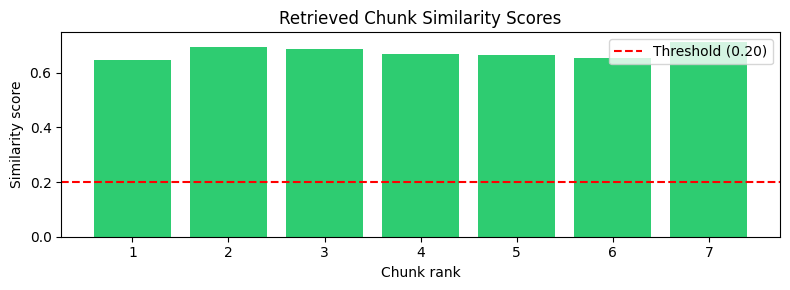

In [13]:
inspect_question = 'What support is available for students with disabilities?'
results = retrieve_top_k(inspect_question)

print(f'Top {len(results)} chunks for: \'{inspect_question}\'\n')
for i, (_, row) in enumerate(results.iterrows(), 1):
    print(f'Chunk {i} — {nice_source_name(row["source_document"])}')
    print(f'  Similarity : {row["similarity_score"]:.3f}')
    print(f'  Word count : {row["word_count"]}')
    print(f'  Text       : {row["text"][:200]}...\n')

# Similarity score distribution plot
scores = results['similarity_score'].values
plt.figure(figsize=(8, 3))
plt.bar(range(1, len(scores)+1), scores, color=['#2ecc71' if s >= 0.3 else '#f39c12' for s in scores])
plt.axhline(0.20, color='red', linestyle='--', label='Threshold (0.20)')
plt.xlabel('Chunk rank')
plt.ylabel('Similarity score')
plt.title('Retrieved Chunk Similarity Scores')
plt.legend()
plt.tight_layout()
plt.show()

## Step 14 — Limitations & Future Work

### Current Limitations

| Limitation | Impact | Severity |
|---|---|---|
| Vocabulary mismatch between student queries and policy language | Some relevant chunks not retrieved | Medium |
| OCR noise in 3 of 6 PDFs | Garbled text reduces embedding quality | Medium |
| Cross-document answers require both relevant chunks to be in TOP_K | Incomplete answers for multi-policy questions | Medium |
| Groq API dependency | System fails without internet/valid key | High |
| Static knowledge base — no auto-update when policies change | Answers may become outdated | Low |
| No memory between questions | Cannot handle follow-up questions in context | Low |

### Suggested Future Improvements

1. **Re-ranking** — Use a cross-encoder model to re-rank retrieved chunks after initial retrieval, improving precision.
2. **Automatic policy monitoring** — Set up a scheduled job to check if policy documents have changed and rebuild the index.
3. **Multilingual support** — Many Makerere students speak Luganda or Swahili. A multilingual embedding model would improve accessibility.
4. **Feedback loop** — Allow students to rate answers (👍/👎) and log low-rated questions for manual review.
5. **Hybrid retrieval** — Combine TF-IDF exact matching with semantic search using Reciprocal Rank Fusion for better coverage.

---
## Summary

| Component | Technology | Why |
|---|---|---|
| Embeddings | `all-MiniLM-L6-v2` (SentenceTransformers) | Fast, strong semantic similarity, runs on CPU |
| Semantic search | Cosine similarity (scikit-learn) | Simple, interpretable, proven effective |
| Baseline | TF-IDF (scikit-learn) | Industry standard for comparison |
| Answer generation | Groq — Llama 3.1 8B Instant | Free, fast, strong instruction following |
| Policy sources | 6 official Makerere University documents | Complete safeguarding coverage |
| Deployment | Hugging Face Spaces (Streamlit) | Free hosting, easy to share |

**Live app:** https://madrine-safeguarding-companion.hf.space